# Logistic Regression — Math Deep Dive

**Goal:** Understand logistic regression from the ground up — the sigmoid, the loss function, gradient derivation, and parameter updates.

---

## 1. Problem Setup

We have a binary classification task. Given input $\mathbf{x} \in \mathbb{R}^n$, we want to predict $y \in \{0, 1\}$.

A linear model produces a raw score:

$$z = \mathbf{w}^\top \mathbf{x} + b$$

Since $z \in (-\infty, +\infty)$ but we need a **probability** in $[0, 1]$, we pass $z$ through the sigmoid function.

## 2. The Sigmoid Function

$$\boxed{\sigma(z) = \frac{1}{1 + e^{-z}}}$$

### Key properties

| Property | Value |
|---|---|
| Range | $(0,\ 1)$ |
| $\sigma(0)$ | $0.5$ |
| $\sigma(+\infty)$ | $\to 1$ |
| $\sigma(-\infty)$ | $\to 0$ |
| Derivative | $\sigma'(z) = \sigma(z)\,(1 - \sigma(z))$ |

### Derivative proof

$$\frac{d\sigma}{dz} = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z)\,(1 - \sigma(z))$$

> The derivative is elegantly self-referential — expressed entirely in terms of $\sigma(z)$ itself.

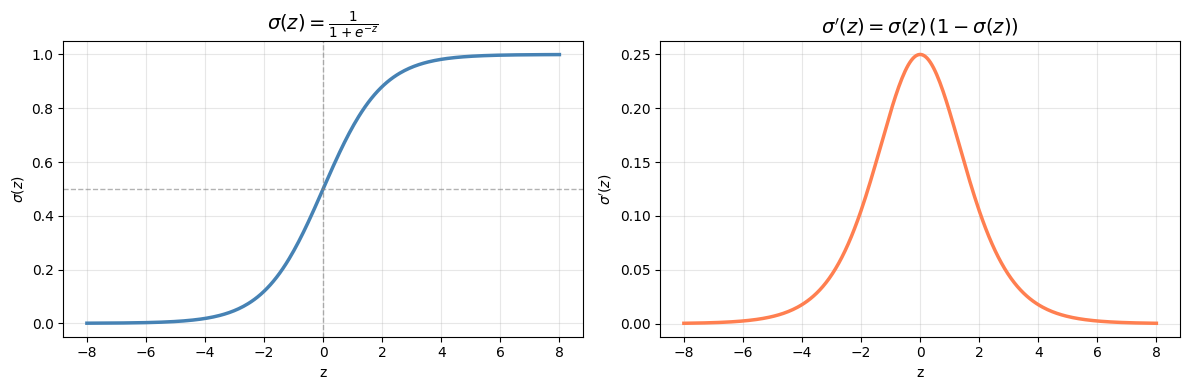

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 300)
sig = sigmoid(z)
dsig = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, sig, color='steelblue', linewidth=2.5)
axes[0].axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].axvline(0,   color='gray', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_title(r'$\sigma(z) = \frac{1}{1+e^{-z}}$', fontsize=14)
axes[0].set_xlabel('z'); axes[0].set_ylabel(r'$\sigma(z)$')
axes[0].set_ylim(-0.05, 1.05); axes[0].grid(alpha=0.3)

axes[1].plot(z, dsig, color='coral', linewidth=2.5)
axes[1].set_title(r"$\sigma'(z) = \sigma(z)\,(1-\sigma(z))$", fontsize=14)
axes[1].set_xlabel('z'); axes[1].set_ylabel(r"$\sigma'(z)$")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. The Model

Our prediction — the estimated probability that $y = 1$ — is:

$$\hat{y} = \sigma(\mathbf{w}^\top \mathbf{x} + b) = P(y=1 \mid \mathbf{x};\, \mathbf{w}, b)$$

And by complement:

$$P(y=0 \mid \mathbf{x}) = 1 - \hat{y}$$

These two cases unify into a single expression:

$$P(y \mid \mathbf{x}) = \hat{y}^{\,y}\,(1-\hat{y})^{1-y}$$

## 4. Loss Function — Binary Cross-Entropy

Taking the negative log of the likelihood above gives the **log loss** for a single example:

$$\boxed{\mathcal{L}(\hat{y},\, y) = -\Big[\, y\log(\hat{y}) + (1-y)\log(1-\hat{y}) \,\Big]}$$

### Why this form?

- When $y = 1$: $\mathcal{L} = -\log(\hat{y})$ — loss is large when $\hat{y} \to 0$
- When $y = 0$: $\mathcal{L} = -\log(1-\hat{y})$ — loss is large when $\hat{y} \to 1$

### Cost over $m$ training examples

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}\!\left(\hat{y}^{(i)},\, y^{(i)}\right)$$

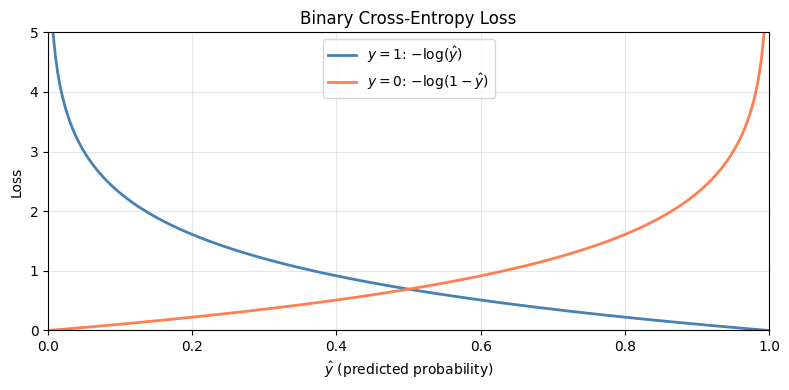

In [ ]:
y_hat = np.linspace(1e-7, 1 - 1e-7, 300)

loss_y1 = -np.log(y_hat)
loss_y0 = -np.log(1 - y_hat)

plt.figure(figsize=(8, 4))
plt.plot(y_hat, loss_y1, label=r'$y=1$: $-\log(\hat{y})$',   color='steelblue', linewidth=2)
plt.plot(y_hat, loss_y0, label=r'$y=0$: $-\log(1-\hat{y})$', color='coral',     linewidth=2)
plt.ylim(0, 5); plt.xlim(0, 1)
plt.xlabel(r'$\hat{y}$ (predicted probability)')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Gradient Descent

We minimize $J(\mathbf{w}, b)$ by iteratively updating parameters in the direction of steepest descent:

$$\mathbf{w} := \mathbf{w} - \alpha \cdot \frac{\partial J}{\partial \mathbf{w}}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

where $\alpha$ is the **learning rate**.

### Gradients averaged over $m$ examples

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m}\, \mathbf{X}^\top (\hat{\mathbf{y}} - \mathbf{y})$$

$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left(\hat{y}^{(i)} - y^{(i)}\right)$$

## 6. Derivation — Why $\dfrac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$

This is the key result. We apply the chain rule:

$$\frac{\partial \mathcal{L}}{\partial z} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z}$$

**Step 1** — differentiate the loss w.r.t. $\hat{y}$:

$$\frac{\partial \mathcal{L}}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$

**Step 2** — sigmoid derivative:

$$\frac{\partial \hat{y}}{\partial z} = \hat{y}\,(1 - \hat{y})$$

**Step 3** — multiply and simplify:

$$\frac{\partial \mathcal{L}}{\partial z} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y})$$

$$= -y(1-\hat{y}) + (1-y)\hat{y}$$

$$\boxed{= \hat{y} - y}$$

> The gradient is simply the **prediction error**. The sigmoid and cross-entropy cancel out each other's complexity — this is why they are always used together.

## 7. Regularization

### L2 (Ridge)

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}^{(i)} + \frac{\lambda}{2m} \|\mathbf{w}\|^2$$

Modified gradient:

$$\frac{\partial J}{\partial \mathbf{w}} = \frac{1}{m}\,\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y}) + \frac{\lambda}{m}\mathbf{w}$$

### L1 (Lasso)

$$J(\mathbf{w}, b) = \frac{1}{m} \sum_{i=1}^{m} \mathcal{L}^{(i)} + \frac{\lambda}{m} \|\mathbf{w}\|_1$$

L1 promotes **sparsity** — many weights go exactly to zero, performing implicit feature selection.

## 8. Full Implementation from Scratch

In [ ]:
import numpy as np

class LogisticRegression:
    def __init__(self, lr=0.1, n_iter=1000, lam=0.0):
        self.lr = lr
        self.n_iter = n_iter
        self.lam = lam
        self.w = None
        self.b = 0.0
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def loss(self, y_hat, y):
        m = len(y)
        eps = 1e-9
        ce = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        reg = (self.lam / (2 * m)) * np.sum(self.w ** 2)
        return ce + reg

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)

        for _ in range(self.n_iter):
            z = X @ self.w + self.b
            y_hat = self.sigmoid(z)
            error = y_hat - y                      # ∂L/∂z = ŷ - y

            dw = (X.T @ error) / m + (self.lam / m) * self.w
            db = np.mean(error)

            self.w -= self.lr * dw
            self.b -= self.lr * db

            self.losses.append(self.loss(y_hat, y))

    def predict_proba(self, X):
        return self.sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

Test accuracy: 0.880


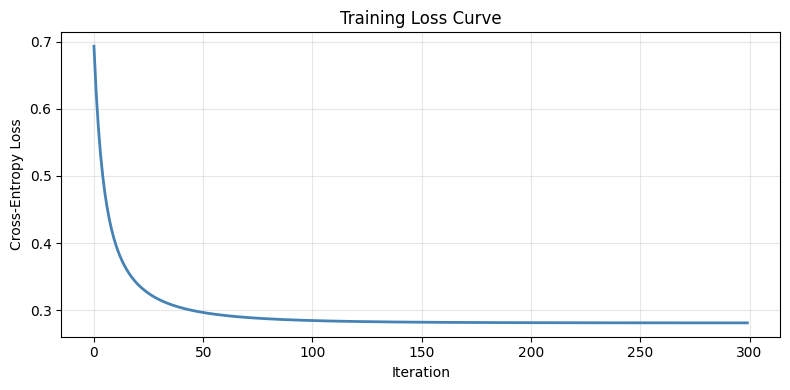

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X, y = make_classification(n_samples=500, n_features=2, n_redundant=0,
                            n_informative=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(lr=0.5, n_iter=300)
model.fit(X_train, y_train)

acc = accuracy_score(y_test, model.predict(X_test))
print(f"Test accuracy: {acc:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(model.losses, color='steelblue', linewidth=2)
plt.xlabel('Iteration'); plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss Curve'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Summary Cheat Sheet

| Step | Formula |
|---|---|
| Linear score | $z = \mathbf{w}^\top \mathbf{x} + b$ |
| Prediction | $\hat{y} = \sigma(z) = \dfrac{1}{1+e^{-z}}$ |
| Loss | $\mathcal{L} = -\big[y\log\hat{y} + (1-y)\log(1-\hat{y})\big]$ |
| Key gradient | $\dfrac{\partial \mathcal{L}}{\partial z} = \hat{y} - y$ |
| Weight update | $\mathbf{w} := \mathbf{w} - \dfrac{\alpha}{m}\,\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$ |
| Bias update | $b := b - \dfrac{\alpha}{m}\displaystyle\sum_i(\hat{y}^{(i)} - y^{(i)})$ |

---

### Key intuitions

- The decision boundary is always a **hyperplane** $\mathbf{w}^\top \mathbf{x} + b = 0$ — logistic regression is a linear classifier.
- Cross-entropy loss comes directly from **MLE under a Bernoulli likelihood** — it's not arbitrary.
- The simplicity of $\hat{y} - y$ is not a coincidence: the sigmoid and log-loss are conjugate pairs that cancel each other's derivatives.